# 2 Calibration Parameters Problem

In [1]:
from jax import config
config.update("jax_enable_x64", True)

# from data.dataloader import DataLoader
from kohgpjax.mappings import mapRto01, map01toR, mapRto0inf, map0inftoR
from jax import jit, grad

import jax.numpy as jnp
import gpjax as gpx
from kohgpjax.base import AbstractKOHModel

import numpy as np
import matplotlib.pyplot as plt

import mici
import arviz

from scipy.stats import gamma

from data.truefuncs import sin1_2 as truefunc

plot_style = {
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'axes.linewidth': 0.5,
    'lines.linewidth': 0.5,
    'axes.labelpad': 2.,
    'figure.dpi': 150,
}

/Users/jamesbriant/miniforge3/envs/micitest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The KOH Model

In [2]:
class Sin1_2(AbstractKOHModel):
    def k_eta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.ProductKernel(
            kernels=[
                gpx.kernels.RBF( # x0
                    active_dims=[0],
                    lengthscale=jnp.array(ells[0]),
                    variance=jnp.array(1/lambdas[0])
                ), 
                gpx.kernels.RBF( # theta0
                    active_dims=[1],
                    lengthscale=jnp.array(ells[1]),
                ),
                gpx.kernels.RBF( # theta1
                    active_dims=[2],
                    lengthscale=jnp.array(ells[2]),
                )
            ]
        )
    
    def k_delta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.RBF(
                active_dims=[0],
                lengthscale=jnp.array(ells[3]),
                variance=jnp.array(1/lambdas[1])
            )

    
    def k_epsilon(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.White(
                active_dims=[0],
                variance=jnp.array(1/lambdas[2])
            )
    
    def k_epsilon_eta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.White(
                active_dims=[0],
                variance=jnp.array(1/lambdas[3])
            )


    def KOH_log_prior(
        self,
        GPJAX_params,
    ):
        thetas, ells, lambdas = GPJAX_params

        ####### ell #######
        # % Prior for ell_eta
        # % EXAMPLE: ell_eta_0 ~ GAM(4,1.4) where 2nd param is rate
        logprior = (4-1)*jnp.log(ells[0]) - 1.4*ells[0]
        # % Prior for ell_eta_1 ~ GAM(2,3.5) where 2nd param is rate
        logprior += (2-1)*jnp.log(ells[1]) - 3.5*ells[1]
        # % Prior for ell_eta_2 ~ GAM(2,2) where 2nd param is rate
        logprior += (2-1)*jnp.log(ells[2]) - 2*ells[2]
        # # % Prior for ell_delta_0 ~ GAM(4,2) where 2nd param is rate
        logprior += (4-1)*jnp.log(ells[3]) - 2*ells[3] # encourage smaller lengthscales on the discrepancy term


        ####### lambda #######
        # % Prior for lambda_eta
        # % EXAMPLE: lambda_eta ~ GAM(2,4) where 2nd param is rate
        # logprior += (2-1)*jnp.log(lambdas[0]) - 4*lambdas[0]
        # % EXAMPLE: lambda_eta ~ GAM(10,10) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[0]) - 10*lambdas[0]

        # % Prior for lambda_b
        # % EXAMPLE: lambda_b ~ GAM(2,0.1) where 2nd param is rate
        # logprior += (2-1)*jnp.log(lambdas[1]) - 0.1*lambdas[1]
        # % EXAMPLE: lambda_b ~ GAM(10,0.3) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[1]) - 0.3*lambdas[1]

        # % Prior for lambda_e
        # % EXAMPLE: lambda_e ~ GAM(12,0.025) where 2nd param is rate
        # logprior += (12-1)*jnp.log(lambdas[2]) - 0.025*lambdas[2]
        # % EXAMPLE: lambda_e ~ GAM(10,0.03) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[2]) - 0.03*lambdas[2]

        # % Prior for lambda_en
        # % EXAMPLE: lambda_en ~ GAM(10,0.001) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[3]) - 0.001*lambdas[3]

        return logprior

## Load data

In [3]:
class DataLoader:
    def __init__(
        self, 
        data_field_path: str = 'data/simple_field.csv', 
        data_comp_path: str = 'data/simple_comp.csv'
    ):
        DATAFIELD = np.loadtxt(data_field_path, delimiter=',', dtype=np.float32)
        DATACOMP = np.loadtxt(data_comp_path, delimiter=',', dtype=np.float32)

        self.yf = np.reshape(DATAFIELD[:, 0], (-1,1))
        self.yc = np.reshape(DATACOMP[:, 0], (-1,1))
        self.xf = np.reshape(DATAFIELD[:, 1], (-1, 1))
        self.xc = np.reshape(DATACOMP[:, 1], (-1,1))
        self.tc = np.reshape(DATACOMP[:, 2:], (-1,2))

        #Standardize full response using mean and std of yc
        self.yc_mean = np.mean(self.yc)

        self.t_min = np.min(self.tc, axis=0)
        self.t_max = np.max(self.tc, axis=0)

        self.yc_centered = self.yc - self.yc_mean
        self.yf_centered = self.yf - self.yc_mean

        self.tc_normalized = (self.tc - self.t_min)/(self.t_max - self.t_min)

        self.x_stack = jnp.vstack((self.xf, self.xc), dtype=np.float64)
        self.y = jnp.vstack((self.yf_centered, self.yc_centered), dtype=np.float64)

    def get_data(self):
        return self.x_stack, self.tc_normalized, self.y
        # return self.x_stack, self.tc, self.y

    def transform_y(self, y):
        return y - self.yc_mean

    def inverse_transform_y(self, y):
        return y + self.yc_mean

In [4]:
dataloader = DataLoader(
    'data/toy/field_sin1_2_simple_growing.csv', 
    'data/toy/sim_sin1_2_simple_growing.csv'
)
data = dataloader.get_data()
model = Sin1_2(*data)

tmax = dataloader.t_max
tmin = dataloader.t_min

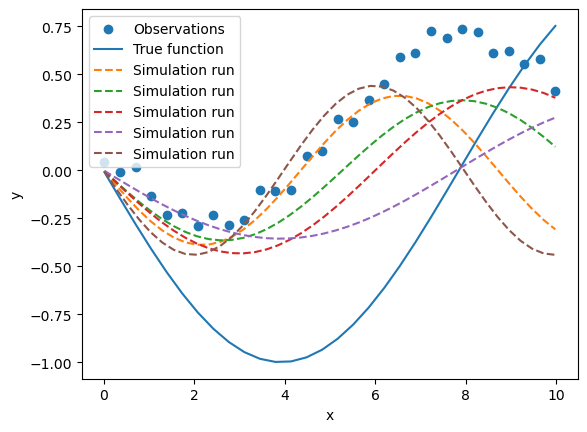

In [5]:
fig, ax = plt.subplots(1, 1)
ax.scatter(dataloader.xf, dataloader.yf, label='Observations')
ax.plot(dataloader.xf, truefunc(dataloader.xf), label='True function')
rng = np.random.default_rng()
ts = rng.permutation(np.unique(dataloader.tc[:,0]))[:5]
for t in ts:
    rows = dataloader.tc[:,0]==t
    ax.plot(dataloader.xc[rows], dataloader.yc[rows], '--', label=f'Simulation run')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

## MCMC Setup

In [6]:
theta_0 = 0.5
theta_1 = 0.25

# ell_eta_0_0 = 1 # np.sqrt(np.var(dataloader.xf))/3
# ell_eta_1_1 = 0.3
# ell_eta_1_2 = 0.3
# ell_delta_0_0 = 1 # np.sqrt(np.var(dataloader.xf))/5

ell_eta_0_0 = 2 # np.sqrt(np.var(dataloader.xf))/3
ell_eta_1_1 = 0.2
ell_eta_1_2 = 0.2
ell_delta_0_0 = 3 # np.sqrt(np.var(dataloader.xf))/5

lambda_eta_0 = 1
lambda_delta_0 = 30
lambda_epsilon_0 = 400
lambda_epsilon_eta_0 = 10000

init_states = np.array([[
    map01toR(theta_0), 
    map01toR(theta_1),
    map0inftoR(ell_eta_0_0),
    map0inftoR(ell_eta_1_1),
    map0inftoR(ell_eta_1_2),
    map0inftoR(ell_delta_0_0),
    map0inftoR(lambda_eta_0),
    map0inftoR(lambda_delta_0),
    map0inftoR(lambda_epsilon_0),
    map0inftoR(lambda_epsilon_eta_0),
]])

In [7]:
param_transform_mici_to_gpjax = lambda x: [
    [ # theta (calibration) parameters
        mapRto01(x[0]),
        mapRto01(x[1]),
        # mapRto01(x[2]),
    ],
    [ # lengthscale parameters
        mapRto0inf(x[2]), 
        mapRto0inf(x[3]), 
        mapRto0inf(x[4]),
        mapRto0inf(x[5]),
    ],
    [ # lambda (variance) parameters
        mapRto0inf(x[8]), 
        mapRto0inf(x[9]), 
        mapRto0inf(x[10]), 
        mapRto0inf(x[11]),
    ]
]

In [8]:
jitted_neg_log_posterior_density = jit(
    model.get_KOH_neg_log_pos_dens_func(
        param_transform_mici_to_gpjax
    )
)
grad_neg_log_posterior_density = jit(grad(
    model.get_KOH_neg_log_pos_dens_func(
        param_transform_mici_to_gpjax
    )
))

def neg_log_pos_dens(x):
    return np.asarray(jitted_neg_log_posterior_density(x))

def grad_neg_log_pos_dens(x):
    return np.asarray(grad_neg_log_posterior_density(x))

##### Mici #####
system = mici.systems.EuclideanMetricSystem(
    neg_log_dens=neg_log_pos_dens,
    grad_neg_log_dens=grad_neg_log_pos_dens,
)
# system = mici.systems.EuclideanMetricSystem(
#     neg_log_dens=neg_log_pos_dens,
#     grad_neg_log_dens=lambda q: q,
# )
integrator = mici.integrators.LeapfrogIntegrator(system)

## Running MCMC algorithm

In [9]:
seed = 1234
n_chain = 1 # only 1 works on MacOS
n_warm_up_iter = 60
n_main_iter = 150
rng = np.random.default_rng(seed)

##### Mici sampler and adapters #####
# sampler = mici.samplers.StaticMetropolisHMC(system, integrator, rng, n_step=1)
# sampler = mici.samplers.StaticMetropolisHMC(system, integrator, rng, n_step=3)
sampler = mici.samplers.DynamicMultinomialHMC(system, integrator, rng)
adapters = [
    mici.adapters.DualAveragingStepSizeAdapter(0.8),
    # mici.adapters.DualAveragingStepSizeAdapter(0.234),
    mici.adapters.OnlineCovarianceMetricAdapter()
]

def trace_func(state):
    return {
        'm_theta_0': state.pos[0], 
        'm_theta_1': state.pos[1],
        'm_ell_eta_0': state.pos[2], 
        'm_ell_eta_1': state.pos[3],
        'm_ell_eta_2': state.pos[4],
        'm_ell_delta_0': state.pos[5],
        'm_lambda_eta': state.pos[6],
        'm_lambda_delta': state.pos[7],
        'm_lambda_epsilon': state.pos[8],
        'm_lambda_epsilon_eta': state.pos[9],
        'hamiltonian': system.h(state)
    }

final_states, traces, stats = sampler.sample_chains(
    n_warm_up_iter, 
    n_main_iter, 
    init_states, 
    adapters=adapters, 
    n_process=n_chain, # only 1 works on MacOS
    trace_funcs=[trace_func]
)

Sampling stage: Initial fast adaptive [05:23] > Slow adaptive (1/1)

Chain 1/1:  17%|█▉        |8/45 [07:46<35:57, 58.31s/it, accept_stat=0.467]

ERROR:mici.samplers:Sampling manually interrupted for chain 1 at iteration 8. Arrays containing chain traces and statistics computed before interruption will be returned.
Traceback (most recent call last):
  File "/Users/jamesbriant/miniforge3/envs/micitest/lib/python3.11/site-packages/mici/samplers.py", line 510, in _sample_chain
    state, trans_stats = transition.sample(state, rng)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/jamesbriant/miniforge3/envs/micitest/lib/python3.11/site-packages/mici/transitions.py", line 731, in sample
    terminate, new_tree, new_proposal = self._build_tree(
                                        ^^^^^^^^^^^^^^^^^
  File "/Users/jamesbriant/miniforge3/envs/micitest/lib/python3.11/site-packages/mici/transitions.py", line 675, in _build_tree
    terminate, inner_tree, inner_proposal = self._build_tree(
                                            ^^^^^^^^^^^^^^^^^
  File "/Users/jamesbriant/miniforge3/envs/micitest/lib/python3.11

## Analyse the raw MCMC chains

In [ ]:
arviz.summary(traces)

Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hamiltonian,-1862.239,51.441,-1951.987,-1789.282,47.707,9.030,1.0,11.0,NaN
m_ell_delta_0,1.993,0.046,1.912,2.066,0.013,0.011,17.0,18.0,NaN
m_ell_eta_0,0.570,0.067,0.472,0.693,0.060,0.011,1.0,33.0,NaN
m_ell_eta_1,-8.252,0.272,-8.726,-7.827,0.230,0.060,1.0,11.0,NaN
m_ell_eta_2,0.973,0.067,0.868,1.090,0.052,0.016,2.0,11.0,NaN
m_lambda_delta,6.013,0.113,5.838,6.209,0.078,0.026,2.0,11.0,NaN
m_lambda_epsilon,-0.358,0.019,-0.393,-0.328,0.015,0.003,1.0,40.0,NaN
m_lambda_epsilon_eta,6.685,0.105,6.519,6.866,0.087,0.024,1.0,11.0,NaN
m_lambda_eta,-4.205,0.117,-4.410,-4.023,0.098,0.025,1.0,11.0,NaN
m_theta_0,-9.175,0.258,-9.635,-8.768,0.202,0.059,2.0,11.0,NaN


In [ ]:
for var, trace in traces.items():
    print(var, ": ", np.mean(trace[0]), '±', np.std(trace[0]))

m_theta_0 :  -9.174805978747 ± 0.2582246469840727
m_theta_1 :  -2.3841287009128282 ± 0.016348026912500188
m_ell_eta_0 :  0.5698708899695599 ± 0.06713789023388657
m_ell_eta_1 :  -8.252021177826347 ± 0.27225285361977114
m_ell_eta_2 :  0.972756335819635 ± 0.06728525047321728
m_ell_delta_0 :  1.9930731430026178 ± 0.046456486265124004
m_lambda_eta :  -4.205255443433353 ± 0.11678032635253358
m_lambda_delta :  6.012836220466559 ± 0.1131614816802379
m_lambda_epsilon :  -0.3576238053305084 ± 0.01864213137394391
m_lambda_epsilon_eta :  6.685089647190576 ± 0.10466963423517768
hamiltonian :  -1862.2387133843558 ± 51.4276941611875


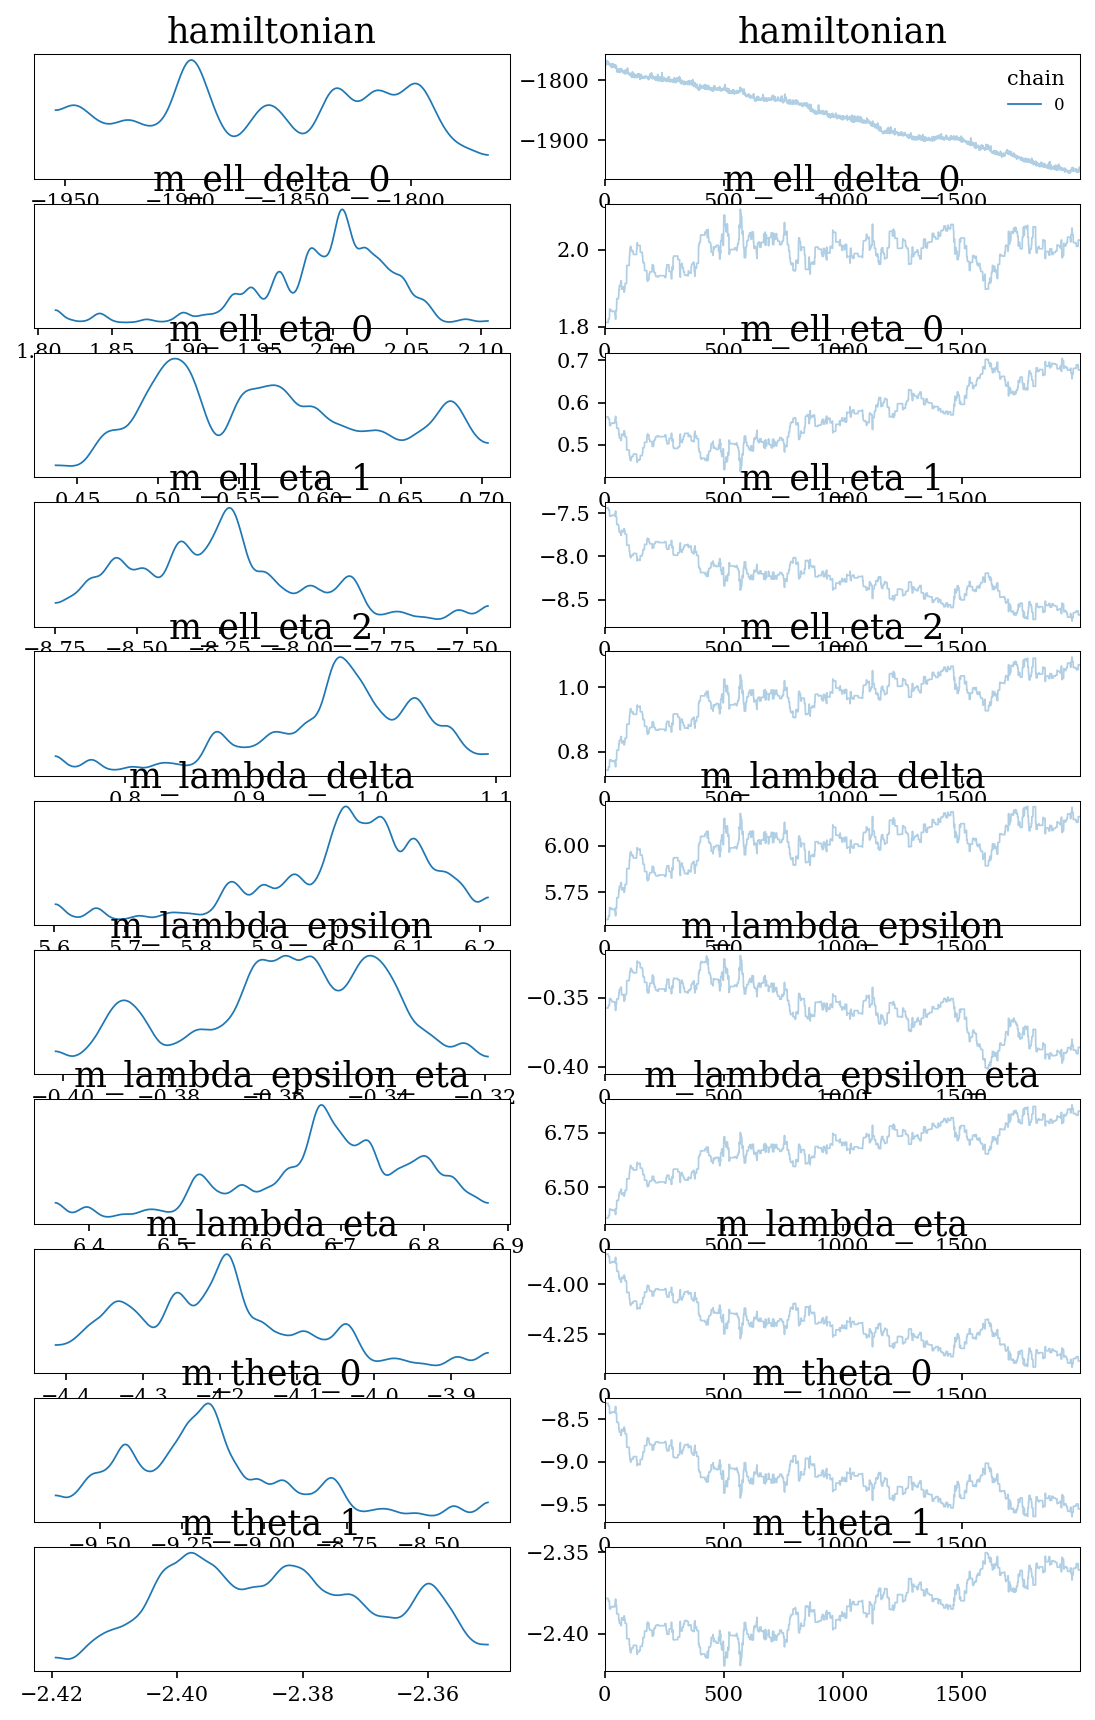

In [ ]:
with plt.style.context(plot_style):
    arviz.plot_trace(
        traces,
        # var_names=["σ", "ϵ", "γ", "β", "x_0"],
        figsize=(9, 2 * (7)),
        legend=True,
        compact=False,
    )


## Analyse the transformed MCMC chains

In [ ]:
traces_transformed = {}
for var, trace in traces.items():
    if var == 'hamiltonian':
        continue
    var_name = var.split('m_')[1]
    if var_name.startswith('theta'):
        theta_num = int(var_name.split('_')[1])
        traces_transformed[var_name] = mapRto01(trace[0])*(tmax[theta_num]-tmin[theta_num]) + tmin[theta_num]
    elif var_name.startswith('ell'):
        traces_transformed[var_name] = mapRto0inf(trace[0])
    elif var_name.startswith('lambda'):
        traces_transformed[var_name] = mapRto0inf(trace[0])

params_transformed = {}
for var, trace in traces_transformed.items():
    params_transformed[var] = np.mean(trace)
    print(var, ": ", np.mean(trace), '±', np.std(trace))

theta_0 :  0.4980961930611217 ± 1.2277312031144707e-05
theta_1 :  -0.36542709765058384 ± 0.0049405379053970655
ell_eta_0 :  1.7720539415195555 ± 0.12016998362184977
ell_eta_1 :  0.0002711083434018929 ± 8.116633643384625e-05
ell_eta_2 :  2.6511005692632006 ± 0.17329562852669678
ell_delta_0 :  7.345824263518532 ± 0.3319999975125264
lambda_eta :  0.015021418179667293 ± 0.0018213586379713473
lambda_delta :  411.16196662531866 ± 43.988598779882224
lambda_epsilon :  0.699457352103243 ± 0.012993245619124509
lambda_epsilon_eta :  804.6764473026283 ± 81.51161121938175


In [ ]:
arviz.summary(traces_transformed)

Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ell_delta_0,7.346,0.332,6.769,7.892,0.095,0.067,17.0,18.0,NaN
ell_eta_0,1.772,0.120,1.589,1.984,0.107,0.021,1.0,33.0,NaN
ell_eta_1,0.000,0.000,0.000,0.000,0.000,0.000,1.0,11.0,NaN
ell_eta_2,2.651,0.173,2.358,2.951,0.136,0.037,2.0,11.0,NaN
lambda_delta,411.162,44.000,341.703,495.604,30.709,8.507,2.0,11.0,NaN
lambda_epsilon,0.699,0.013,0.675,0.720,0.011,0.002,1.0,40.0,NaN
lambda_epsilon_eta,804.676,81.532,677.826,959.046,68.201,16.955,1.0,11.0,NaN
lambda_eta,0.015,0.002,0.012,0.018,0.002,0.000,1.0,11.0,NaN
theta_0,0.498,0.000,0.498,0.498,0.000,0.000,2.0,11.0,NaN
theta_1,-0.365,0.005,-0.374,-0.357,0.004,0.001,1.0,21.0,NaN


**NOTE**: The red priors below are probably different from the priors used above. Please ignore these red priors.

/Users/jamesbriant/miniforge3/envs/pygjpax09/lib/python3.11/site-packages/arviz/plots/backends/matplotlib/traceplot.py:218: UserWarning: A valid var_name should be provided, found {'theta'} expected from {'theta_1', 'lambda_epsilon', 'theta_0', 'ell_eta_2', 'lambda_eta', 'lambda_epsilon_eta', 'ell_eta_1', 'ell_eta_0', 'ell_delta_0', 'lambda_delta'}
  warnings.warn(


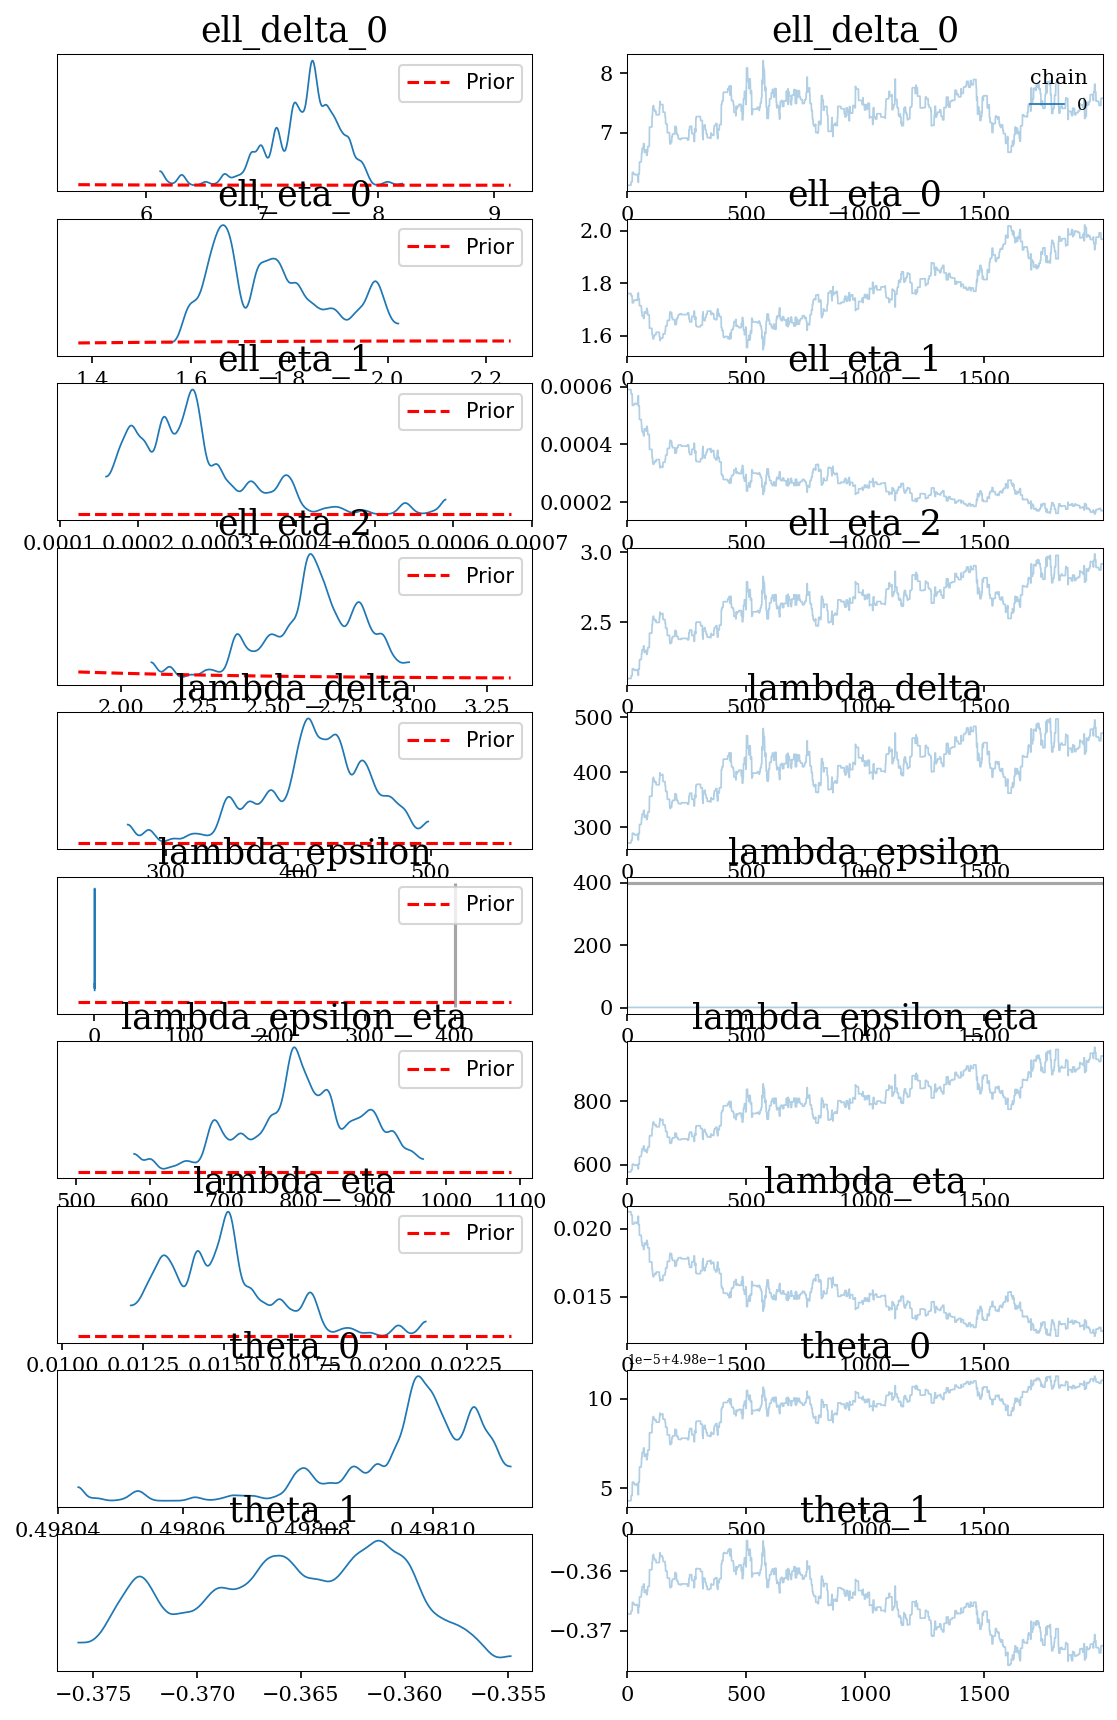

In [ ]:
priors = {
    # 'ell_delta_0': [4, 1],
    'ell_delta_0': [4, 2],
    'ell_delta_1': [4, 2],
    'ell_eta_0': [4, 1.4],
    'ell_eta_1': [2, 3.5],
    'ell_eta_2': [2, 2],
    'ell_eta_3': [2, 2],
    # 'lambda_delta': [10, 0.3],
    'lambda_delta': [2, 0.1],
    'lambda_epsilon': [12, 0.025],
    'lambda_epsilon_eta': [10, 0.001],
    'lambda_eta': [2, 4],
}

with plt.style.context(plot_style):
    axes = arviz.plot_trace(
        traces_transformed,
        figsize=(9, 2 * (7)),
        legend=True,
        compact=False,
        lines=(
            ('theta', {}, 0.4),
            ('lambda_epsilon', {}, 1/0.05**2)    
        )
    )
for i in range(axes.shape[0]):
    left, right = axes[i, 0].get_xlim()
    left, right = left*0.9, right*1.1
    x = np.linspace(left, right, 1000)
    title = axes[i, 0].get_title()
    if title in priors:
        alpha, beta = priors[title]
        pdf = gamma.pdf(x, a=alpha, scale=1/beta)
        axes[i, 0].plot(x, pdf, color='red', linestyle='--', label='Prior')
        axes[i, 0].legend()
plt.show()